In [4]:
import sys
import os

# Go up one level to repo root
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.datasets import load_california_housing

sns.set_theme(style="whitegrid")
data = load_california_housing()
X_train = data["X_train"]
y_train = data["y_train"]
feature_names = data["feature_names"]

print("Train samples:", X_train.shape[0])
print("Features:     ", X_train.shape[1])

Train samples: 16512
Features:      8


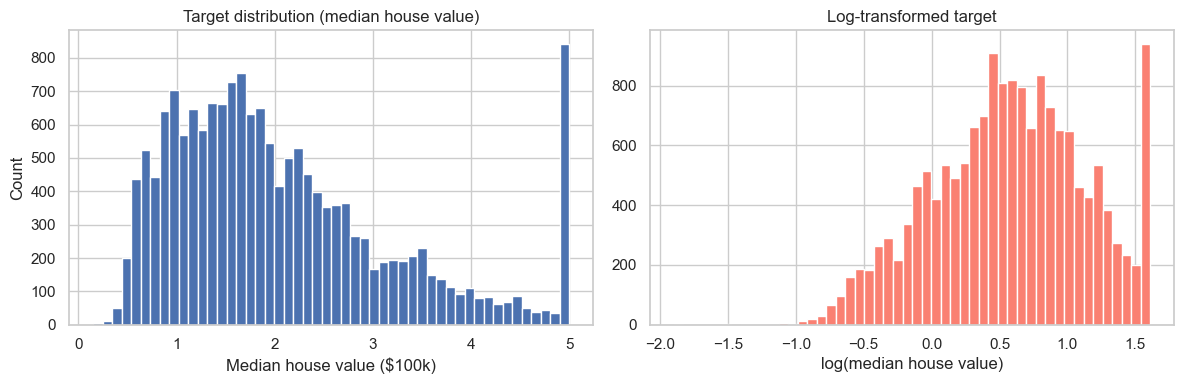

Skewness: 0.976


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, edgecolor="white")
axes[0].set_title("Target distribution (median house value)")
axes[0].set_xlabel("Median house value ($100k)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(y_train), bins=50, edgecolor="white", color="salmon")
axes[1].set_title("Log-transformed target")
axes[1].set_xlabel("log(median house value)")

plt.tight_layout()
plt.savefig("../reports/figures/cal_target_distribution.pdf")
plt.show()
print("Skewness:", round(float(np.mean((y_train - y_train.mean())**3)
      / y_train.std()**3), 3))

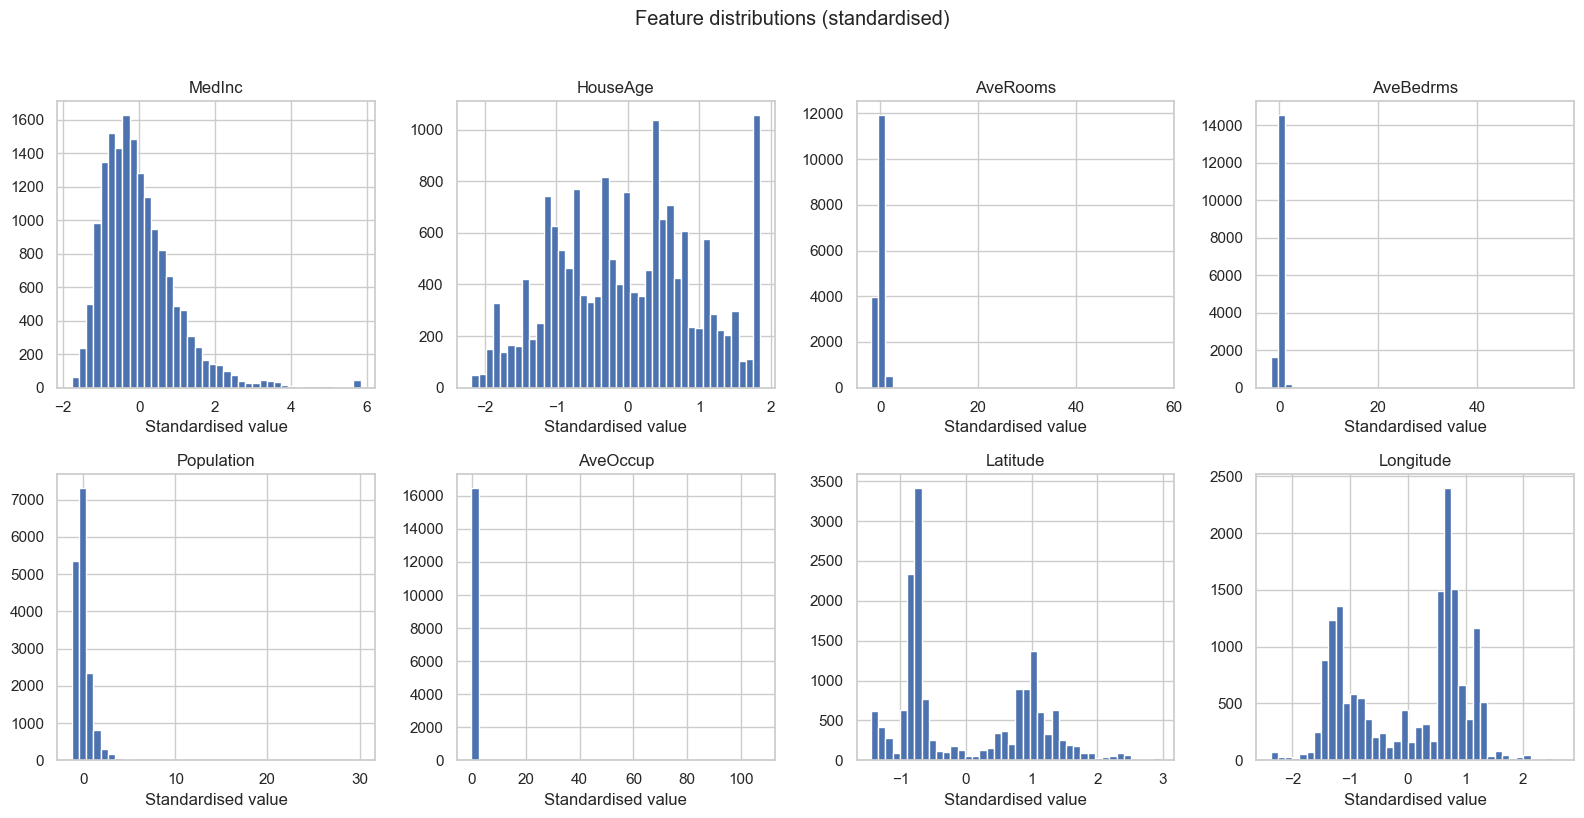

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    axes[i].hist(X_train[:, i], bins=40, edgecolor="white")
    axes[i].set_title(name)
    axes[i].set_xlabel("Standardised value")

plt.suptitle("Feature distributions (standardised)", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/cal_feature_distributions.pdf")
plt.show()

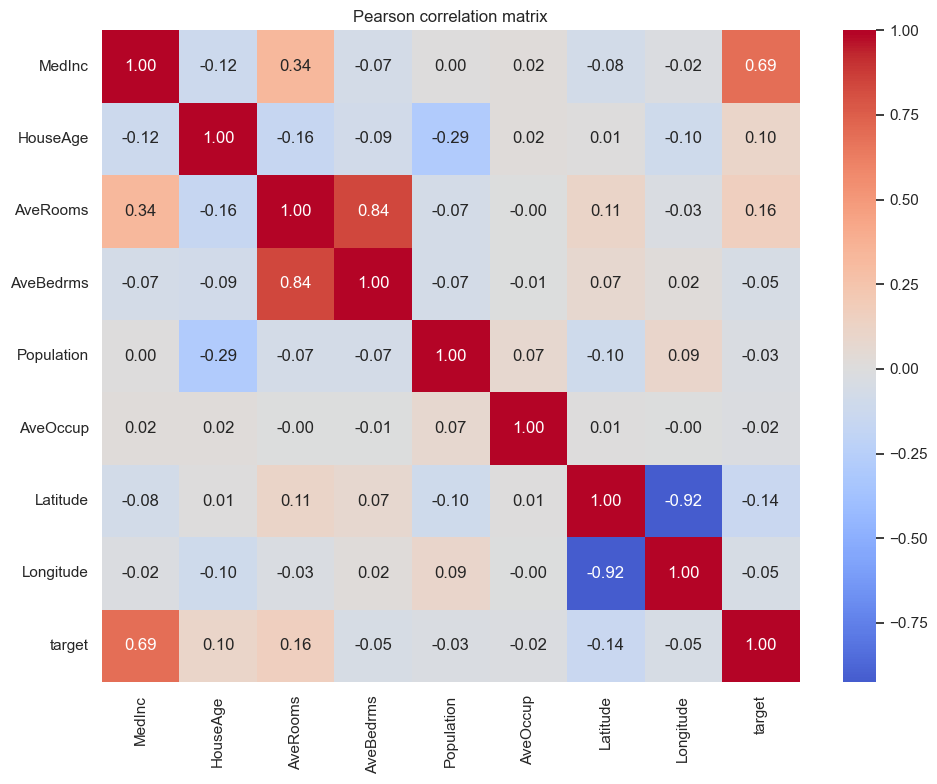

In [8]:
import pandas as pd

df = pd.DataFrame(X_train, columns=feature_names)
df["target"] = y_train

corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.savefig("../reports/figures/cal_correlation_heatmap.pdf")
plt.show()

C:\Users\ramfe\AppData\Local\Temp\ipykernel_34432\616764241.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=labels)


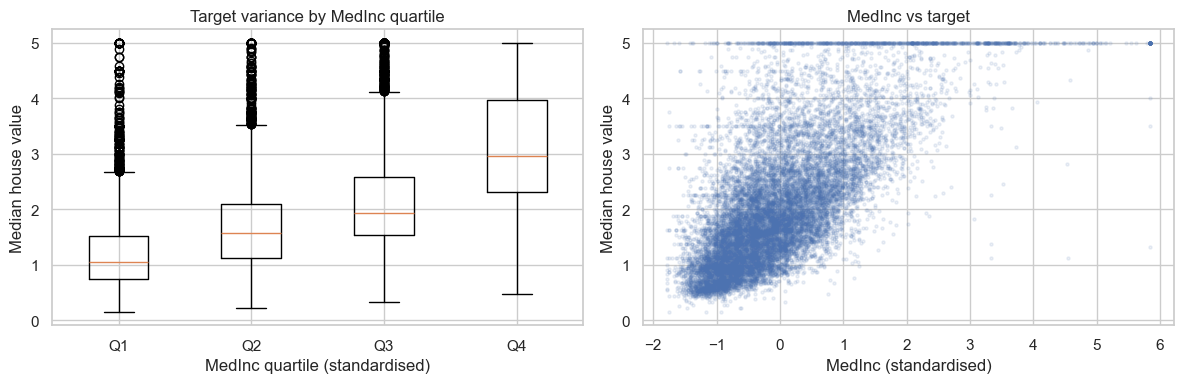

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Does variance of target vary with MedInc?
medinc = X_train[:, feature_names.index("MedInc")]
quartiles = np.percentile(medinc, [0, 25, 50, 75, 100])

groups = []
labels = []
for i in range(4):
    mask = (medinc >= quartiles[i]) & (medinc < quartiles[i+1])
    groups.append(y_train[mask])
    labels.append(f"Q{i+1}")

axes[0].boxplot(groups, labels=labels)
axes[0].set_title("Target variance by MedInc quartile")
axes[0].set_xlabel("MedInc quartile (standardised)")
axes[0].set_ylabel("Median house value")

# Scatter: MedInc vs target
axes[1].scatter(medinc, y_train, alpha=0.1, s=5)
axes[1].set_title("MedInc vs target")
axes[1].set_xlabel("MedInc (standardised)")
axes[1].set_ylabel("Median house value")

plt.tight_layout()
plt.savefig("../reports/figures/cal_heteroscedasticity.pdf")
plt.show()